# E-Commerce Return Analysis

## Project Objective

To analyze customer and order characteristics associated with product returns and develop a machine learning model to predict orders that are likely to be returned.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- SQL
- Power BI

In [1]:
import pandas as pd

In [11]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Ecommerce_Return_Analysis\data\raw\ecommerce_sales_34500.csv")

In [4]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [12]:
df.shape

(34500, 17)

In [13]:
df.columns.tolist()

['order_id',
 'customer_id',
 'product_id',
 'category',
 'price',
 'discount',
 'quantity',
 'payment_method',
 'order_date',
 'delivery_time_days',
 'region',
 'returned',
 'total_amount',
 'shipping_cost',
 'profit_margin',
 'customer_age',
 'customer_gender']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [14]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['returned'].value_counts()

returned
No     32597
Yes     1903
Name: count, dtype: int64

In [17]:
df['returned'].value_counts(normalize=True) * 100

returned
No     94.484058
Yes     5.515942
Name: proportion, dtype: float64

# Data Understanding and Cleaning

Data cleaning is performed to ensure that the dataset is suitable for statistical analysis and machine learning. The process includes checking data types, missing values, duplicate records, categorical variables, and invalid numerical values.

In [18]:
df_clean = df.copy()

In [19]:
df_clean.dtypes

order_id               object
customer_id            object
product_id             object
category               object
price                 float64
discount              float64
quantity                int64
payment_method         object
order_date             object
delivery_time_days      int64
region                 object
returned               object
total_amount          float64
shipping_cost         float64
profit_margin         float64
customer_age            int64
customer_gender        object
dtype: object

In [20]:
df_clean['order_date'] = pd.to_datetime(
    df_clean['order_date'],
    errors='coerce'
)

In [21]:
df_clean['order_date'].dtype

dtype('<M8[ns]')

In [22]:
df_clean.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [23]:
df_clean.duplicated().sum()

np.int64(0)

In [24]:
df_clean['order_id'].duplicated().sum()

np.int64(0)

In [25]:
df_clean.describe()

,price,discount,quantity,order_date,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,2024-09-13 13:39:17.843478272,4.814203,170.008494,6.152120,28.116505,43.474377
min,1.010000,0.000000,1.000000,2023-09-12 00:00:00,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,2024-03-14 00:00:00,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,2024-09-16 00:00:00,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,2025-03-17 00:00:00,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,2025-09-11 00:00:00,13.000000,12931.800000,15.650000,1536.170000,69.000000
std,195.620477,0.069894,0.932270,NaN,1.242141,357.503014,2.389539,53.352947,14.980682


In [26]:
print("Categories:")
print(df_clean['category'].unique())

print("\nPayment Methods:")
print(df_clean['payment_method'].unique())

print("\nRegions:")
print(df_clean['region'].unique())

print("\nGender:")
print(df_clean['customer_gender'].unique())

print("\nReturn Status:")
print(df_clean['returned'].unique())

Categories:
['Home' 'Grocery' 'Electronics' 'Beauty' 'Fashion' 'Toys' 'Sports']

Payment Methods:
['Credit Card' 'UPI' 'COD' 'PayPal' 'Debit Card' 'Wallet']

Regions:
['West' 'South' 'North' 'East' 'Central']

Gender:
['Female' 'Male' 'Other']

Return Status:
['No' 'Yes']


In [27]:
print("Price <= 0:", (df_clean['price'] <= 0).sum())
print("Quantity <= 0:", (df_clean['quantity'] <= 0).sum())
print("Invalid discount:", ((df_clean['discount'] < 0) | (df_clean['discount'] > 1)).sum())
print("Delivery days <= 0:", (df_clean['delivery_time_days'] <= 0).sum())
print("Invalid age:", ((df_clean['customer_age'] < 0) | (df_clean['customer_age'] > 100)).sum())

Price <= 0: 0
Quantity <= 0: 0
Invalid discount: 0
Delivery days <= 0: 0
Invalid age: 0


In [28]:
df_clean.to_csv(
    "../data/cleaned/ecommerce_sales_cleaned.csv",
    index=False
)

# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the e-commerce transactions and identify patterns associated with product returns. The analysis examines the overall return rate and investigates how returns vary across product categories, regions, payment methods, customer demographics, discounts, delivery time, quantity, and price.

## Overall Return Distribution

The distribution of returned and non-returned orders is examined to understand the proportion of orders that are returned. This also helps identify whether the target variable is balanced or imbalanced.

In [29]:
return_counts = df_clean['returned'].value_counts()

print(return_counts)

returned
No     32597
Yes     1903
Name: count, dtype: int64


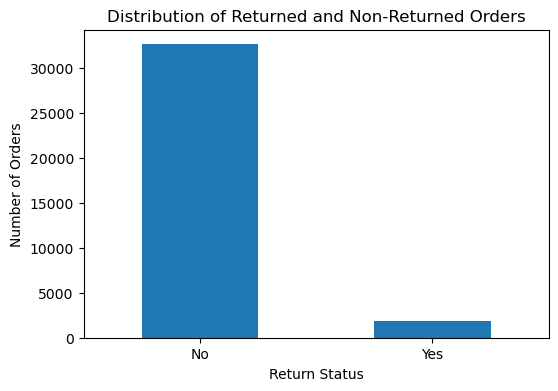

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))

return_counts.plot(kind='bar')

plt.title('Distribution of Returned and Non-Returned Orders')
plt.xlabel('Return Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.show()

In [34]:
return_rate = (df_clean['returned'] == 'Yes').mean() * 100

print(f"Overall Return Rate: {return_rate:.2f}%")

Overall Return Rate: 5.52%


## Return Rate by Product Category

Different product categories may have different return behaviors. The return rate for each category is calculated to identify categories with comparatively higher or lower return rates.

In [35]:
category_returns = (
    df_clean.groupby('category')['returned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

category_returns

category
Fashion        8.282699
Electronics    7.297735
Home           5.649718
Toys           4.944667
Sports         4.938864
Beauty         3.777724
Grocery        1.306062
Name: returned, dtype: float64

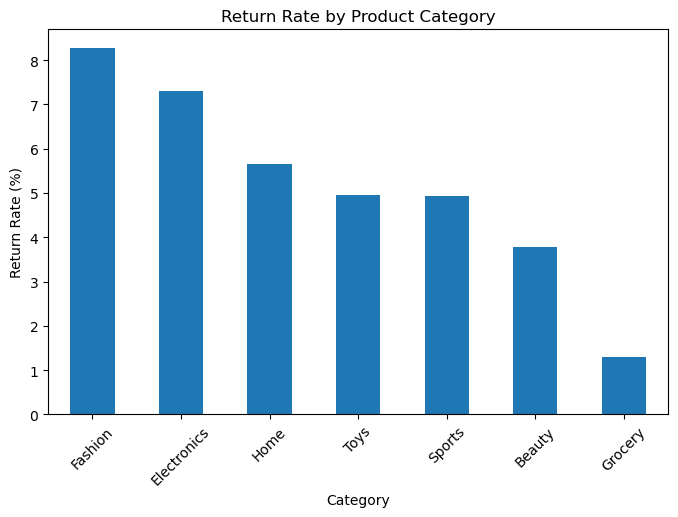

In [36]:
plt.figure(figsize=(8, 5))

category_returns.plot(kind='bar')

plt.title('Return Rate by Product Category')
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)

plt.show()

## Return Rate by Region

The return rate is analyzed across different geographical regions to determine whether return behavior varies by location.

In [37]:
region_returns = (
    df_clean.groupby('region')['returned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

region_returns

region
East       5.909618
South      5.683017
West       5.449471
North      5.361859
Central    5.095881
Name: returned, dtype: float64

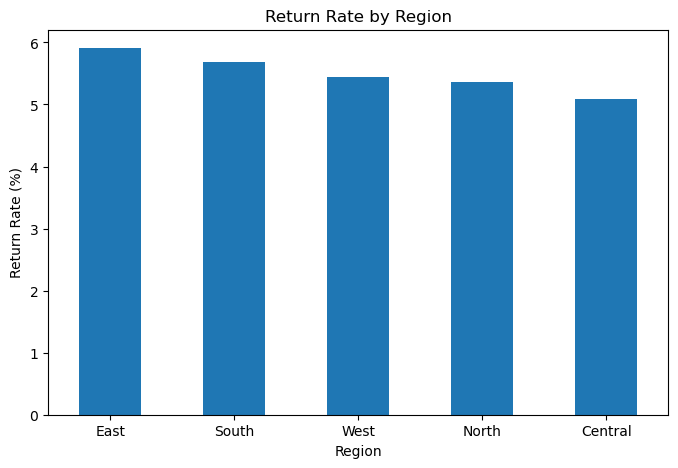

In [38]:
plt.figure(figsize=(8, 5))

region_returns.plot(kind='bar')

plt.title('Return Rate by Region')
plt.xlabel('Region')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0)

plt.show()

##  Return Rate by Payment Method

The relationship between payment method and product returns is examined to determine whether return behavior differs across payment channels.

In [39]:
payment_returns = (
    df_clean.groupby('payment_method')['returned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

payment_returns

payment_method
PayPal         5.778165
Debit Card     5.667255
Credit Card    5.546426
UPI            5.389798
Wallet         5.375303
COD            5.096154
Name: returned, dtype: float64

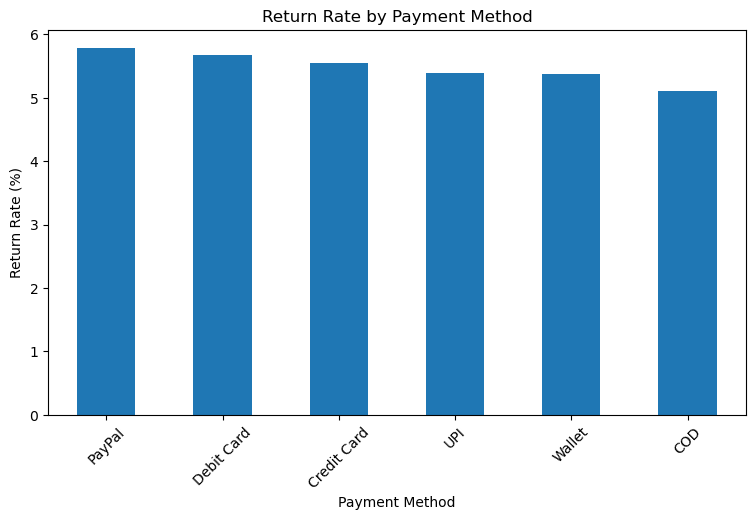

In [40]:
plt.figure(figsize=(9, 5))

payment_returns.plot(kind='bar')

plt.title('Return Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)

plt.show()

## Return Rate by Customer Gender

Customer gender is analyzed to determine whether there are differences in return behavior across gender groups.

In [41]:
gender_returns = (
    df_clean.groupby('customer_gender')['returned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

gender_returns

customer_gender
Female    5.618980
Male      5.438381
Other     5.174927
Name: returned, dtype: float64

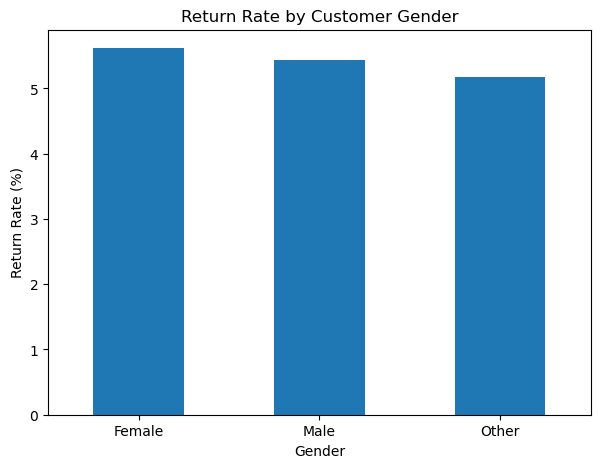

In [42]:
plt.figure(figsize=(7, 5))

gender_returns.plot(kind='bar')

plt.title('Return Rate by Customer Gender')
plt.xlabel('Gender')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0)

plt.show()

## Customer Age Distribution

Customer age is examined to understand the demographic distribution of the dataset and investigate whether age may be associated with product returns.

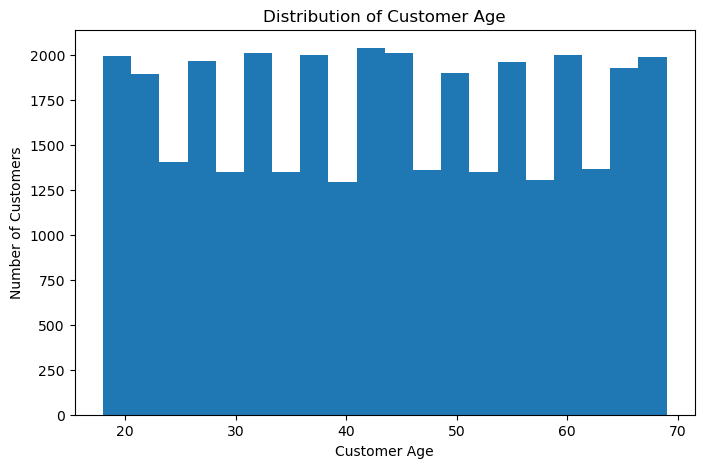

In [43]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean['customer_age'], bins=20)

plt.title('Distribution of Customer Age')
plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')

plt.show()

In [44]:
df_clean['age_group'] = pd.cut(
    df_clean['customer_age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['Under 18', '18-30', '31-45', '46-60', 'Above 60']
)

In [45]:
df_clean['age_group'].value_counts().sort_index()

age_group
Under 18      647
18-30        7970
31-45       10037
46-60        9901
Above 60     5945
Name: count, dtype: int64

In [46]:
age_returns = (
    df_clean.groupby('age_group', observed=True)['returned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

age_returns

age_group
Under 18    5.255023
18-30       5.407779
31-45       5.788582
46-60       5.383295
Above 60    5.449958
Name: returned, dtype: float64

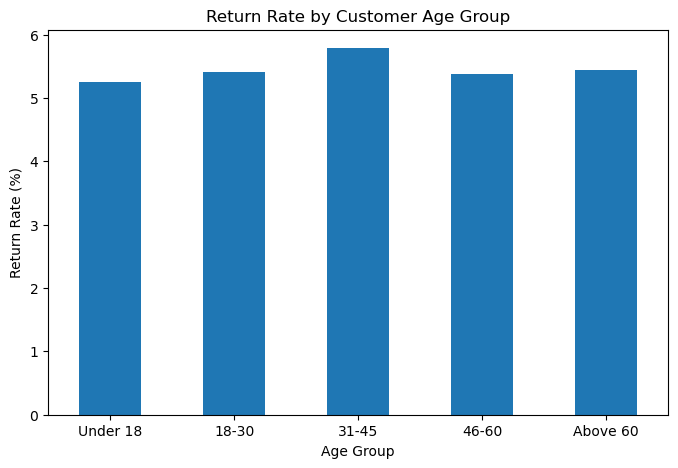

In [47]:
plt.figure(figsize=(8, 5))

age_returns.plot(kind='bar')

plt.title('Return Rate by Customer Age Group')
plt.xlabel('Age Group')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0)

plt.show()

## Discount and Product Returns

Discount levels are analyzed to determine whether the extent of discount applied to an order is associated with the likelihood of a return.

In [48]:
df_clean['discount'].describe()

count    34500.000000
mean         0.049291
std          0.069894
min          0.000000
25%          0.000000
50%          0.000000
75%          0.100000
max          0.300000
Name: discount, dtype: float64

In [49]:
df_clean['discount_group'] = pd.cut(
    df_clean['discount'],
    bins=[-0.01, 0.10, 0.20, 0.30, 0.40, 1.00],
    labels=['0-10%', '11-20%', '21-30%', '31-40%', 'Above 40%']
)

In [50]:
discount_returns = (
    df_clean.groupby('discount_group', observed=True)['returned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

discount_returns

discount_group
0-10%     5.547585
11-20%    5.506413
21-30%    4.261364
Name: returned, dtype: float64

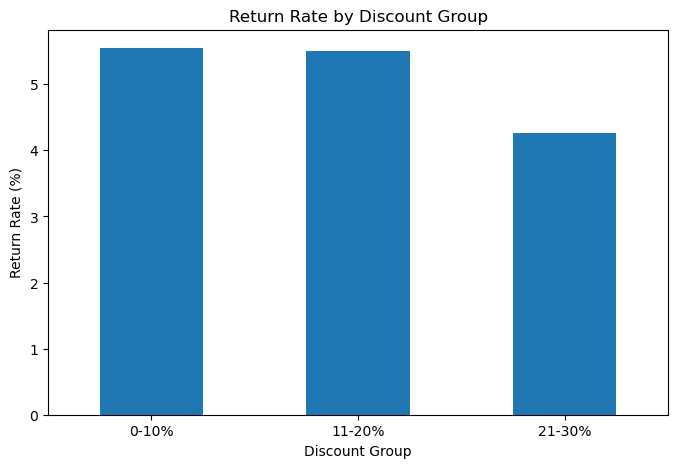

In [51]:
plt.figure(figsize=(8, 5))

discount_returns.plot(kind='bar')

plt.title('Return Rate by Discount Group')
plt.xlabel('Discount Group')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0)

plt.show()

## Delivery Time and Product Returns

Delivery time is analyzed to determine whether longer delivery periods are associated with a higher likelihood of product returns.

In [52]:
df_clean['delivery_time_days'].describe()

count    34500.000000
mean         4.814203
std          1.242141
min          3.000000
25%          4.000000
50%          5.000000
75%          6.000000
max         13.000000
Name: delivery_time_days, dtype: float64

In [53]:
df_clean['delivery_group'] = pd.cut(
    df_clean['delivery_time_days'],
    bins=[0, 3, 5, 7, 10, float('inf')],
    labels=['1-3 Days', '4-5 Days', '6-7 Days', '8-10 Days', 'Above 10 Days']
)

In [54]:
delivery_returns = (
    df_clean.groupby('delivery_group', observed=True)['returned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

delivery_returns

delivery_group
1-3 Days         5.237416
4-5 Days         5.527219
6-7 Days         5.597417
8-10 Days        6.071429
Above 10 Days    0.000000
Name: returned, dtype: float64

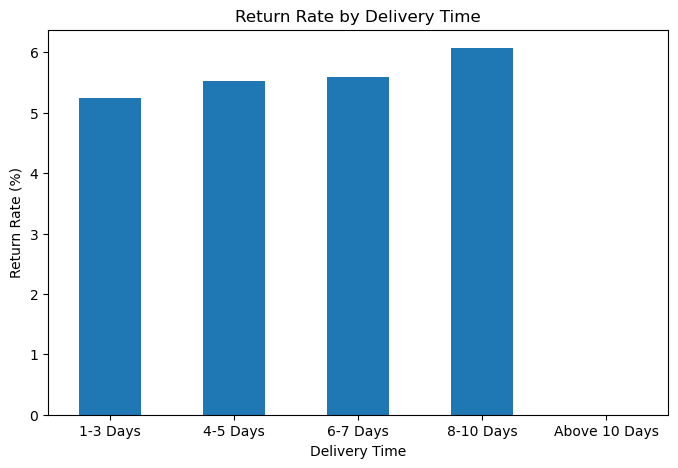

In [55]:
plt.figure(figsize=(8, 5))

delivery_returns.plot(kind='bar')

plt.title('Return Rate by Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0)

plt.show()

## Correlation Analysis

Correlation analysis is used to examine the relationships between numerical variables in the dataset. It helps identify variables that may have useful relationships with transaction characteristics and return behavior.

In [56]:
df_corr = df_clean.copy()

df_corr['returned_numeric'] = df_corr['returned'].map({
    'No': 0,
    'Yes': 1
})

In [57]:
numeric_cols = [
    'price',
    'discount',
    'quantity',
    'delivery_time_days',
    'total_amount',
    'shipping_cost',
    'profit_margin',
    'customer_age',
    'returned_numeric'
]

correlation_matrix = df_corr[numeric_cols].corr()

correlation_matrix

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age,returned_numeric
price,1.000000,0.008736,0.005324,0.007612,0.801426,0.654110,0.679105,-0.010550,0.031785
discount,0.008736,1.000000,-0.008431,0.002490,-0.031202,-0.046383,-0.047470,0.000181,-0.003091
quantity,0.005324,-0.008431,1.000000,0.005120,0.304134,0.278292,0.388398,0.000352,0.000702
delivery_time_days,0.007612,0.002490,0.005120,1.000000,0.005495,0.007651,0.005832,0.003624,0.004556
total_amount,0.801426,-0.031202,0.304134,0.005495,1.000000,0.599079,0.893327,-0.009870,0.023167
shipping_cost,0.654110,-0.046383,0.278292,0.007651,0.599079,1.000000,0.616730,-0.008951,0.048624
profit_margin,0.679105,-0.047470,0.388398,0.005832,0.893327,0.616730,1.000000,-0.007712,0.019752
customer_age,-0.010550,0.000181,0.000352,0.003624,-0.009870,-0.008951,-0.007712,1.000000,-0.000922
returned_numeric,0.031785,-0.003091,0.000702,0.004556,0.023167,0.048624,0.019752,-0.000922,1.000000


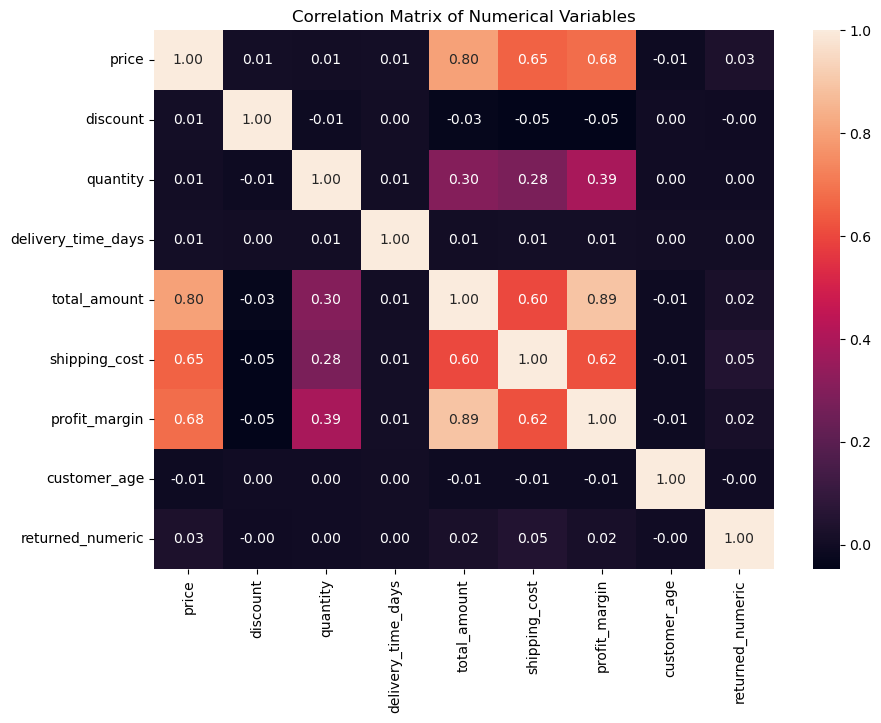

In [62]:
import seaborn as sns
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

## EDA Summary

The exploratory analysis provides an understanding of the factors associated with e-commerce product returns. Return rates are compared across product categories, regions, payment methods, customer demographics, discount levels, and delivery times. These findings help identify potentially important predictors that can be used during the machine learning stage.

## Feature Engineering

Feature engineering is the process of transforming existing variables into meaningful features that can improve machine learning performance. New features are created from customer age, delivery time, discount, and order date to provide additional information for predicting product returns.

In [64]:
import pandas as pd
import numpy as np

df_ml = df_clean.copy()

print("Dataset shape:", df_ml.shape)
print("\nColumns:")
print(df_ml.columns.tolist())

Dataset shape: (34500, 20)

Columns:
['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivery_time_days', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender', 'age_group', 'discount_group', 'delivery_group']


In [65]:
print("Dataset shape:", df_ml.shape)
print(df_ml.columns.tolist())

Dataset shape: (34500, 20)
['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivery_time_days', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender', 'age_group', 'discount_group', 'delivery_group']


## Check Existing Engineered Features

The dataset already contains engineered features including age group, discount group, and delivery group. These features will be examined before preparing the data for machine learning.

In [66]:
print("Age Group:")
print(df_ml['age_group'].value_counts())

print("\nDiscount Group:")
print(df_ml['discount_group'].value_counts())

print("\nDelivery Group:")
print(df_ml['delivery_group'].value_counts())

Age Group:
age_group
31-45       10037
46-60        9901
18-30        7970
Above 60     5945
Under 18      647
Name: count, dtype: int64

Discount Group:
discount_group
0-10%        29274
11-20%        4522
21-30%         704
31-40%           0
Above 40%        0
Name: count, dtype: int64

Delivery Group:
delivery_group
4-5 Days         20390
6-7 Days          8361
1-3 Days          4907
8-10 Days          840
Above 10 Days        2
Name: count, dtype: int64


In [67]:
df_ml['order_date'] = pd.to_datetime(
    df_ml['order_date'],
    errors='coerce'
)

print(df_ml['order_date'].dtype)

datetime64[ns]


## Date-Based Feature Engineering

The order date is transformed into separate time-based features such as year, month, day of week, and weekend indicator. These features may capture temporal patterns associated with customer returns.

In [68]:
df_ml['order_year'] = df_ml['order_date'].dt.year
df_ml['order_month'] = df_ml['order_date'].dt.month
df_ml['order_dayofweek'] = df_ml['order_date'].dt.dayofweek

df_ml['is_weekend'] = (
    df_ml['order_dayofweek'] >= 5
).astype(int)

In [69]:
df_ml[
    [
        'order_date',
        'order_year',
        'order_month',
        'order_dayofweek',
        'is_weekend'
    ]
].head()

,order_date,order_year,order_month,order_dayofweek,is_weekend
0,2023-12-23,2023,12,5,1
1,2025-04-03,2025,4,3,0
2,2024-10-08,2024,10,1,0
3,2024-09-14,2024,9,5,1
4,2024-12-21,2024,12,5,1


## Create Numerical Target Variable

The returned variable is converted into a binary target. A value of 0 represents an order that was not returned, while 1 represents a returned order.

In [70]:
df_ml['returned_target'] = df_ml['returned'].map({
    'No': 0,
    'Yes': 1
})

In [71]:
print(df_ml['returned_target'].value_counts())

returned_target
0    32597
1     1903
Name: count, dtype: int64


In [72]:
print(df_ml.isnull().sum())

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
age_group             0
discount_group        0
delivery_group        0
order_year            0
order_month           0
order_dayofweek       0
is_weekend            0
returned_target       0
dtype: int64


In [73]:
print("Final shape:", df_ml.shape)

print("\nColumns:")
print(df_ml.columns.tolist())

Final shape: (34500, 25)

Columns:
['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivery_time_days', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender', 'age_group', 'discount_group', 'delivery_group', 'order_year', 'order_month', 'order_dayofweek', 'is_weekend', 'returned_target']


In [74]:
print("Final shape:", df_ml.shape)
print(df_ml.isnull().sum())

Final shape: (34500, 25)
order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
age_group             0
discount_group        0
delivery_group        0
order_year            0
order_month           0
order_dayofweek       0
is_weekend            0
returned_target       0
dtype: int64


## Feature and Target Selection

The returned_target variable is used as the target variable for predicting whether an order will be returned. Identifier columns and the original return variable are excluded because they do not provide useful predictive information and may cause data leakage.

In [75]:
# Target variable
y = df_ml['returned_target']

# Features
X = df_ml.drop(
    columns=[
        'returned_target',
        'returned',
        'order_id',
        'customer_id',
        'product_id'
    ]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (34500, 20)
y shape: (34500,)


In [76]:
print("\nNumerical columns:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include='object').columns.tolist())


Numerical columns:
['price', 'discount', 'quantity', 'delivery_time_days', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'order_year', 'order_month', 'order_dayofweek', 'is_weekend']

Categorical columns:
['category', 'payment_method', 'region', 'customer_gender']


In [77]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['price', 'discount', 'quantity', 'delivery_time_days', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'is_weekend']

Categorical features:
['category', 'payment_method', 'region', 'customer_gender', 'age_group', 'discount_group', 'delivery_group']


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (27600, 20)
X_test: (6900, 20)
y_train: (27600,)
y_test: (6900,)


In [79]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [80]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed X_train:", X_train_processed.shape)
print("Processed X_test:", X_test_processed.shape)

Processed X_train: (27600, 43)
Processed X_test: (6900, 43)


In [81]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining return rate:")
print(round(y_train.mean() * 100, 2), "%")

print("\nTesting return rate:")
print(round(y_test.mean() * 100, 2), "%")

Training target distribution:
returned_target
0    26078
1     1522
Name: count, dtype: int64

Testing target distribution:
returned_target
0    6519
1     381
Name: count, dtype: int64

Training return rate:
5.51 %

Testing return rate:
5.52 %


In [82]:
print("X shape:", X.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Processed X_train:", X_train_processed.shape)

X shape: (34500, 20)
X_train: (27600, 20)
X_test: (6900, 20)
Processed X_train: (27600, 43)


## Logistic Regression

Logistic Regression is used as the baseline classification model for predicting product returns. Since returned orders represent a minority class in the dataset, class balancing is applied to improve the model's ability to identify returned orders.

In [83]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

In [84]:
logistic_model.fit(
    X_train_processed,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [85]:
y_pred_lr = logistic_model.predict(
    X_test_processed
)

y_prob_lr = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [87]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))
print("ROC-AUC  :", round(roc_auc_lr, 4))

Logistic Regression Results
--------------------------------
Accuracy : 0.5378
Precision: 0.0727
Recall   : 0.6273
F1 Score : 0.1304
ROC-AUC  : 0.6166


In [88]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print("Confusion Matrix:")
print(cm_lr)

Confusion Matrix:
[[3472 3047]
 [ 142  239]]


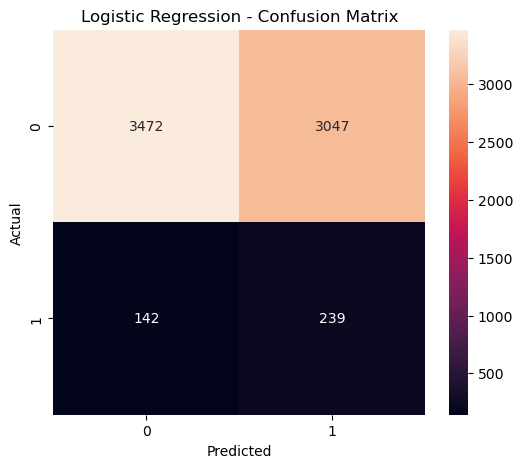

In [89]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')

plt.show()

In [90]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Not Returned', 'Returned']
    )
)

              precision    recall  f1-score   support

Not Returned       0.96      0.53      0.69      6519
    Returned       0.07      0.63      0.13       381

    accuracy                           0.54      6900
   macro avg       0.52      0.58      0.41      6900
weighted avg       0.91      0.54      0.65      6900



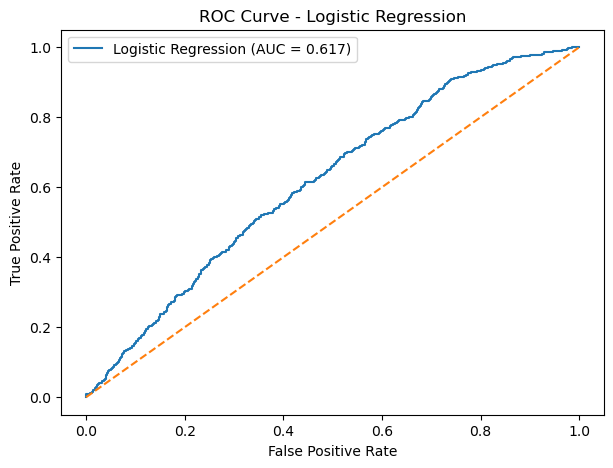

In [91]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, thresholds_lr = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()

plt.show()

In [92]:
logistic_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_lr,
    'Precision': precision_lr,
    'Recall': recall_lr,
    'F1 Score': f1_lr,
    'ROC-AUC': roc_auc_lr
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.5378260869565218,
 'Precision': 0.07273280584297018,
 'Recall': 0.6272965879265092,
 'F1 Score': 0.13035178620125443,
 'ROC-AUC': np.float64(0.6165998118159759)}

## Random Forest

Random Forest is an ensemble classification algorithm that combines multiple decision trees to improve prediction performance. It is used as the second machine learning model to predict whether an e-commerce order will be returned.

In [93]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [94]:
random_forest_model.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [95]:
y_pred_rf = random_forest_model.predict(
    X_test_processed
)

y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

In [96]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest Results
--------------------------------
Accuracy : 0.9448
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5677


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [97]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[6519    0]
 [ 381    0]]


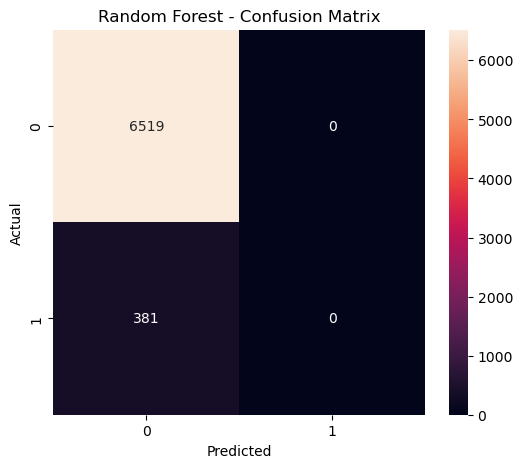

In [98]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')

plt.show()

In [99]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['Not Returned', 'Returned']
    )
)

              precision    recall  f1-score   support

Not Returned       0.94      1.00      0.97      6519
    Returned       0.00      0.00      0.00       381

    accuracy                           0.94      6900
   macro avg       0.47      0.50      0.49      6900
weighted avg       0.89      0.94      0.92      6900



C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


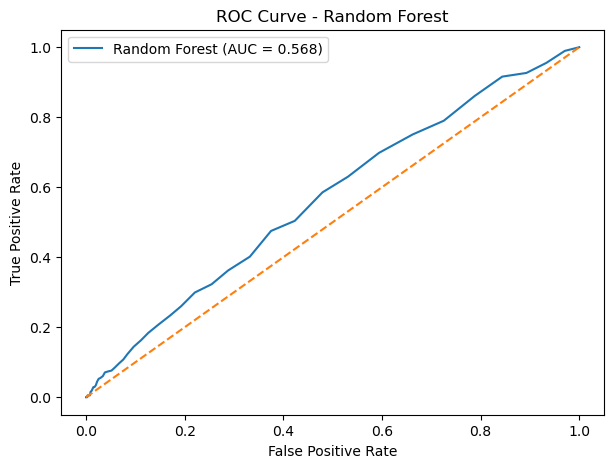

In [100]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_rf:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()

plt.show()

In [101]:
random_forest_results = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1 Score': f1_rf,
    'ROC-AUC': roc_auc_rf
}

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.9447826086956522,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1 Score': 0.0,
 'ROC-AUC': np.float64(0.5676856545715955)}

In [102]:
print("Minimum probability:", y_prob_rf.min())
print("Maximum probability:", y_prob_rf.max())
print("Average probability:", y_prob_rf.mean())

Minimum probability: 0.0
Maximum probability: 0.4
Average probability: 0.05494855072463769


In [103]:
print(
    pd.Series(y_prob_rf).describe()
)

count    6900.000000
mean        0.054949
std         0.042173
min         0.000000
25%         0.025000
50%         0.045000
75%         0.075000
max         0.400000
dtype: float64


In [104]:
threshold = 0.30

y_pred_rf_30 = (
    y_prob_rf >= threshold
).astype(int)

In [105]:
accuracy_rf_30 = accuracy_score(
    y_test,
    y_pred_rf_30
)

precision_rf_30 = precision_score(
    y_test,
    y_pred_rf_30,
    zero_division=0
)

recall_rf_30 = recall_score(
    y_test,
    y_pred_rf_30
)

f1_rf_30 = f1_score(
    y_test,
    y_pred_rf_30
)

print("Random Forest - Threshold 0.30")
print("--------------------------------")
print("Accuracy :", round(accuracy_rf_30, 4))
print("Precision:", round(precision_rf_30, 4))
print("Recall   :", round(recall_rf_30, 4))
print("F1 Score :", round(f1_rf_30, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest - Threshold 0.30
--------------------------------
Accuracy : 0.9435
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5677


In [106]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=12,
                       min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [107]:
y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Minimum probability:", y_prob_rf.min())
print("Maximum probability:", y_prob_rf.max())
print("Average probability:", y_prob_rf.mean())

Minimum probability: 0.007297146769352414
Maximum probability: 0.6347311127326147
Average probability: 0.36346353068166865


In [108]:
threshold = 0.20

y_pred_rf = (
    y_prob_rf >= threshold
).astype(int)

In [109]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest Results")
print("--------------------------------")
print("Threshold:", threshold)
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest Results
--------------------------------
Threshold: 0.2
Accuracy : 0.1954
Precision: 0.0617
Recall   : 0.9554
F1 Score : 0.1159
ROC-AUC  : 0.6132


In [110]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.05, 0.66, 0.01):

    y_pred_temp = (
        y_prob_rf >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_temp,
        zero_division=0
    )

    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    'F1 Score',
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1 Score
43,0.48,0.091714,0.299213,0.140394
41,0.46,0.084515,0.375328,0.137964
42,0.47,0.086160,0.333333,0.136927
40,0.45,0.080955,0.409449,0.135182
39,0.44,0.079199,0.456693,0.134988
38,0.43,0.076480,0.488189,0.132243
37,0.42,0.075213,0.532808,0.131818
32,0.37,0.071214,0.748031,0.130048
33,0.38,0.071447,0.711286,0.129851
36,0.41,0.072764,0.572178,0.129109


In [112]:
# Find the threshold with the best F1 score

best_threshold = threshold_df.loc[
    threshold_df['F1 Score'].idxmax(),
    'Threshold'
]

print("Best Threshold:", best_threshold)

Best Threshold: 0.48


In [113]:
y_pred_rf_best = (
    y_prob_rf >= best_threshold
).astype(int)

print("Best threshold predictions created successfully.")

Best threshold predictions created successfully.


In [114]:
accuracy_rf_best = accuracy_score(
    y_test,
    y_pred_rf_best
)

precision_rf_best = precision_score(
    y_test,
    y_pred_rf_best,
    zero_division=0
)

recall_rf_best = recall_score(
    y_test,
    y_pred_rf_best,
    zero_division=0
)

f1_rf_best = f1_score(
    y_test,
    y_pred_rf_best,
    zero_division=0
)

print("Final Random Forest Results")
print("--------------------------------")
print("Best Threshold:", best_threshold)
print("Accuracy :", round(accuracy_rf_best, 4))
print("Precision:", round(precision_rf_best, 4))
print("Recall   :", round(recall_rf_best, 4))
print("F1 Score :", round(f1_rf_best, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Final Random Forest Results
--------------------------------
Best Threshold: 0.48
Accuracy : 0.7977
Precision: 0.0917
Recall   : 0.2992
F1 Score : 0.1404
ROC-AUC  : 0.6132


## Model Evaluation and Comparison

Logistic Regression and Random Forest are compared using accuracy, precision, recall, F1-score, and ROC-AUC. Since returned orders represent a minority class, F1-score, recall, and ROC-AUC are given greater importance than accuracy alone.

In [115]:
model_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_lr,
        'Precision': precision_lr,
        'Recall': recall_lr,
        'F1 Score': f1_lr,
        'ROC-AUC': roc_auc_lr
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_rf_best,
        'Precision': precision_rf_best,
        'Recall': recall_rf_best,
        'F1 Score': f1_rf_best,
        'ROC-AUC': roc_auc_rf
    }
])

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.537826,0.072733,0.627297,0.130352,0.616600
1,Random Forest,0.797681,0.091714,0.299213,0.140394,0.613208


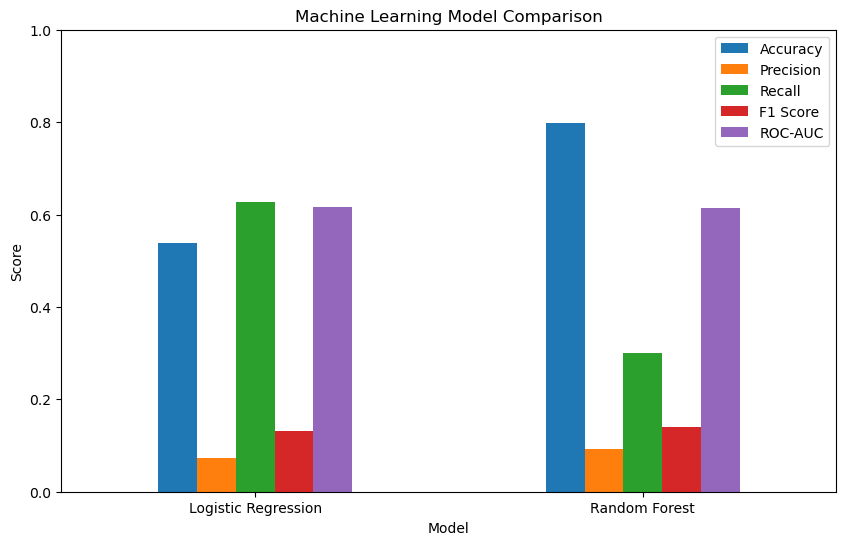

In [116]:
model_comparison.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Machine Learning Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [117]:
best_model_f1 = model_comparison.loc[
    model_comparison['F1 Score'].idxmax()
]

print("Best Model based on F1 Score:")
print(best_model_f1)

Best Model based on F1 Score:
Model        Random Forest
Accuracy          0.797681
Precision         0.091714
Recall            0.299213
F1 Score          0.140394
ROC-AUC           0.613208
Name: 1, dtype: object


In [118]:
print("Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Confusion Matrix
[[3472 3047]
 [ 142  239]]


In [119]:
print("\nRandom Forest Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf_best))


Random Forest Confusion Matrix
[[5390 1129]
 [ 267  114]]


In [120]:
print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Not Returned', 'Returned']
    )
)

print("\nRANDOM FOREST")
print(
    classification_report(
        y_test,
        y_pred_rf_best,
        target_names=['Not Returned', 'Returned']
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

Not Returned       0.96      0.53      0.69      6519
    Returned       0.07      0.63      0.13       381

    accuracy                           0.54      6900
   macro avg       0.52      0.58      0.41      6900
weighted avg       0.91      0.54      0.65      6900


RANDOM FOREST
              precision    recall  f1-score   support

Not Returned       0.95      0.83      0.89      6519
    Returned       0.09      0.30      0.14       381

    accuracy                           0.80      6900
   macro avg       0.52      0.56      0.51      6900
weighted avg       0.91      0.80      0.84      6900



## Return Prediction

The trained Logistic Regression model is used to generate return probabilities for all orders. These probabilities are converted into return predictions and risk categories to support business decision-making.

In [121]:
# Transform the complete feature dataset
X_processed = preprocessor.transform(X)

# Generate return probabilities
return_probability = logistic_model.predict_proba(
    X_processed
)[:, 1]

# Generate binary predictions
predicted_return = (
    return_probability >= 0.50
).astype(int)

print("Number of predictions:", len(predicted_return))
print("Predicted returns:", predicted_return.sum())

Number of predictions: 34500
Predicted returns: 16755


In [122]:
df_final = df_ml.copy()

df_final['Predicted_Return'] = predicted_return

df_final['Return_Probability'] = return_probability

print(df_final.shape)

(34500, 27)


In [123]:
df_final['Risk_Score'] = (
    df_final['Return_Probability'] * 100
).round(2)

In [124]:
df_final['Risk_Category'] = pd.cut(
    df_final['Return_Probability'],
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=['Low', 'Medium', 'High']
)

In [125]:
print(
    df_final['Risk_Category'].value_counts()
)

Risk_Category
Medium    25661
High       4744
Low        4095
Name: count, dtype: int64


In [126]:
print(
    df_final[
        [
            'returned',
            'Predicted_Return',
            'Return_Probability',
            'Risk_Score',
            'Risk_Category'
        ]
    ].head(10)
)

  returned  Predicted_Return  Return_Probability  Risk_Score Risk_Category
0       No                 1            0.503237       50.32        Medium
1       No                 0            0.206803       20.68           Low
2       No                 1            0.565577       56.56        Medium
3       No                 0            0.492720       49.27        Medium
4       No                 0            0.425241       42.52        Medium
5       No                 0            0.428083       42.81        Medium
6       No                 1            0.600677       60.07          High
7       No                 0            0.397815       39.78        Medium
8       No                 1            0.619164       61.92          High
9       No                 0            0.178158       17.82           Low


In [127]:
risk_summary = df_final.groupby(
    'Risk_Category',
    observed=False
).agg(
    total_orders=('order_id', 'count'),
    returned_orders=('returned_target', 'sum'),
    average_return_probability=('Return_Probability', 'mean')
).reset_index()

risk_summary['actual_return_rate'] = (
    risk_summary['returned_orders']
    / risk_summary['total_orders']
    * 100
).round(2)

risk_summary

,Risk_Category,total_orders,returned_orders,average_return_probability,actual_return_rate
0,Low,4095,53,0.185700,1.29
1,Medium,25661,1435,0.494766,5.59
2,High,4744,415,0.625183,8.75


## Final ML Dataset

The final dataset combines the original transaction information, engineered features, machine learning predictions, return probabilities, risk scores, and risk categories. This dataset will be exported for visualization and business analysis in Power BI.

In [128]:
print("Final dataset shape:", df_final.shape)

print("\nFinal columns:")
print(df_final.columns.tolist())

Final dataset shape: (34500, 29)

Final columns:
['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivery_time_days', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender', 'age_group', 'discount_group', 'delivery_group', 'order_year', 'order_month', 'order_dayofweek', 'is_weekend', 'returned_target', 'Predicted_Return', 'Return_Probability', 'Risk_Score', 'Risk_Category']


In [129]:
final_file = "ecommerce_final_ml_dataset.csv"

df_final.to_csv(
    final_file,
    index=False
)

print("File exported successfully:", final_file)

File exported successfully: ecommerce_final_ml_dataset.csv


In [130]:
import os

print("File exists:", os.path.exists(final_file))
print(
    "File size:",
    round(os.path.getsize(final_file) / (1024 * 1024), 2),
    "MB"
)

File exists: True
File size: 5.57 MB


In [131]:
df_check = pd.read_csv(final_file)

print("Reloaded dataset shape:", df_check.shape)

Reloaded dataset shape: (34500, 29)


In [132]:
import os

print(os.getcwd())

C:\Users\ASUS\OneDrive\Desktop\Ecommerce_Return_Analysis\notebook
